In [1]:
print("Hello World")

Hello World


In [2]:
helo = "Hai"
print(helo)

Hai


Membaca & Melihat data

In [3]:
import pandas as pd

df = pd.read_csv("best-selling-manga.csv", na_values=["-"])

df.head()

,Manga series,Author(s),Publisher,Demographic,No. of collected volumes,Serialized,Approximate sales in million(s),Average sales per volume in million(s)
0,One Piece,Eiichiro Oda,Shueisha,Shōnen,104,1997–present,516.6,4.97
1,Golgo 13,"Takao Saito, Saito Production",Shogakukan,Seinen,207,1968–present,300.0,1.45
2,Case Closed / Detective Conan,Gosho Aoyama,Shogakukan,Shōnen,102,1994–present,270.0,2.65
3,Dragon Ball,Akira Toriyama,Shueisha,Shōnen,42,1984–1995,260.0,6.19
4,Doraemon,Fujiko F. Fujio,Shogakukan,Children,45,1969–1996,250.0,4.71


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Manga series                            187 non-null    str    
 1   Author(s)                               187 non-null    str    
 2   Publisher                               187 non-null    str    
 3   Demographic                             187 non-null    str    
 4   No. of collected volumes                187 non-null    int64  
 5   Serialized                              187 non-null    str    
 6   Approximate sales in million(s)         187 non-null    float64
 7   Average sales per volume in million(s)  187 non-null    float64
dtypes: float64(2), int64(1), str(5)
memory usage: 11.8 KB


In [5]:
df.describe()

,No. of collected volumes,Approximate sales in million(s),Average sales per volume in million(s)
count,187.000000,187.000000,187.000000
mean,46.048128,50.764332,1.377380
std,34.678288,57.178028,1.240013
min,5.000000,20.000000,0.190000
25%,23.500000,24.500000,0.670000
50%,34.000000,31.000000,1.030000
75%,56.500000,50.500000,1.650000
max,207.000000,516.600000,10.000000


In [6]:
df.shape

(187, 8)

In [7]:
df.tail()

,Manga series,Author(s),Publisher,Demographic,No. of collected volumes,Serialized,Approximate sales in million(s),Average sales per volume in million(s)
182,Sukeban Deka,Shinji Wada,Hakusensha,Shōjo,22,1976–1982,20.0,0.90
183,Swan,Kyoko Ariyoshi,Shueisha,Shōjo,21,1976–1981,20.0,0.95
184,The Tale of Genji,Waki Yamato,Kodansha,Shōjo,13,1980–1993,20.0,1.53
185,Tokyo Daigaku Monogatari,Tatsuya Egawa,Shogakukan,Seinen,34,1992–2001,20.0,0.58
186,Weed,Yoshihiro Takahashi,Nihon Bungeisha,Seinen,60,1999–2009,20.0,0.33


Membersihkan Data

In [8]:
df["No. of collected volumes"] = df["No. of collected volumes"].fillna(0)

In [9]:
df = df.dropna()

In [10]:
df = df.drop_duplicates()

In [11]:
df.tail()

,Manga series,Author(s),Publisher,Demographic,No. of collected volumes,Serialized,Approximate sales in million(s),Average sales per volume in million(s)
182,Sukeban Deka,Shinji Wada,Hakusensha,Shōjo,22,1976–1982,20.0,0.90
183,Swan,Kyoko Ariyoshi,Shueisha,Shōjo,21,1976–1981,20.0,0.95
184,The Tale of Genji,Waki Yamato,Kodansha,Shōjo,13,1980–1993,20.0,1.53
185,Tokyo Daigaku Monogatari,Tatsuya Egawa,Shogakukan,Seinen,34,1992–2001,20.0,0.58
186,Weed,Yoshihiro Takahashi,Nihon Bungeisha,Seinen,60,1999–2009,20.0,0.33


In [12]:
# df["tanggal"] = pd.to_datetime(df["Published"], errors='coerce')
# mengubah tipe data tanggal

Menyaring & Mengelompokkan data

In [13]:
# Menyaring data dengan demographic "Seinen" dan menampilkan 5 baris pertama
df_seinen = df[df["Demographic"] == "Seinen"]
df_seinen.head()

,Manga series,Author(s),Publisher,Demographic,No. of collected volumes,Serialized,Approximate sales in million(s),Average sales per volume in million(s)
1,Golgo 13,"Takao Saito, Saito Production",Shogakukan,Seinen,207,1968–present,300.0,1.45
9,Oishinbo,"Tetsu Kariya, Akira Hanasaki",Shogakukan,Seinen,111,1983–2014 (on hiatus),135.0,1.22
18,Kingdom,Yasuhisa Hara,Shueisha,Seinen,68,2006–present,97.0,1.42
24,Vagabond,Takehiko Inoue,Kodansha,Seinen,37,1998–2015 (on hiatus),82.0,2.21
37,Crayon Shin-chan,"Yoshito Usui, UY Team",Futabasha,Seinen,61,1990–present,58.0,0.95


In [14]:
# mengelompokkan & agregasi
rata_per_averagesSales = df.groupby("Demographic")["Average sales per volume in million(s)"].mean()
rata_per_averagesSales.head()

Demographic
Children       1.552500
Josei          1.125000
Seinen         0.968600
Shōjo          1.292857
Shōjo/Josei    0.330000
Name: Average sales per volume in million(s), dtype: float64

In [15]:
# Mengurutkan data berdasarkan kolom "Average sales per volume in million(s)" secara menurun dan menampilkan 5 baris pertama
df_sorted = df.sort_values("Average sales per volume in million(s)", ascending=False)
df_sorted.head()

,Manga series,Author(s),Publisher,Demographic,No. of collected volumes,Serialized,Approximate sales in million(s),Average sales per volume in million(s)
50,Devilman,Go Nagai,Kodansha,Shōnen,5,1972–1973,50.0,10.00
8,Demon Slayer: Kimetsu no Yaiba,Koyoharu Gotouge,Shueisha,Shōnen,23,2016–2020,150.0,6.52
3,Dragon Ball,Akira Toriyama,Shueisha,Shōnen,42,1984–1995,260.0,6.19
6,Slam Dunk,Takehiko Inoue,Shueisha,Shōnen,31,1990–1996,170.0,5.48
0,One Piece,Eiichiro Oda,Shueisha,Shōnen,104,1997–present,516.6,4.97


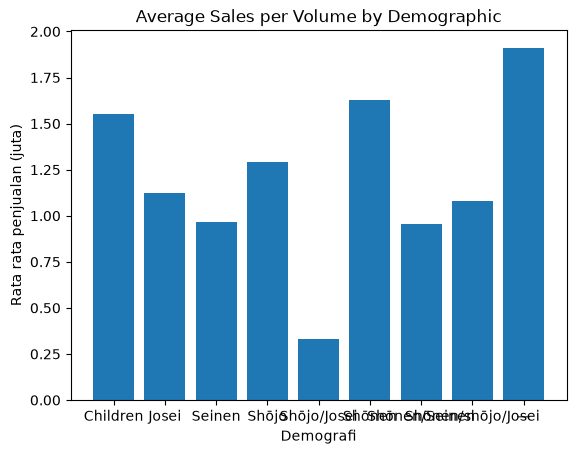

In [16]:
import matplotlib.pyplot as plt

# Bar Chart Sederhana
plt.bar(rata_per_averagesSales.index, rata_per_averagesSales.values)
plt.title("Average Sales per Volume by Demographic")
plt.xlabel("Demografi")
plt.ylabel("Rata rata penjualan (juta)")
plt.show()

In [17]:
import seaborn as sns

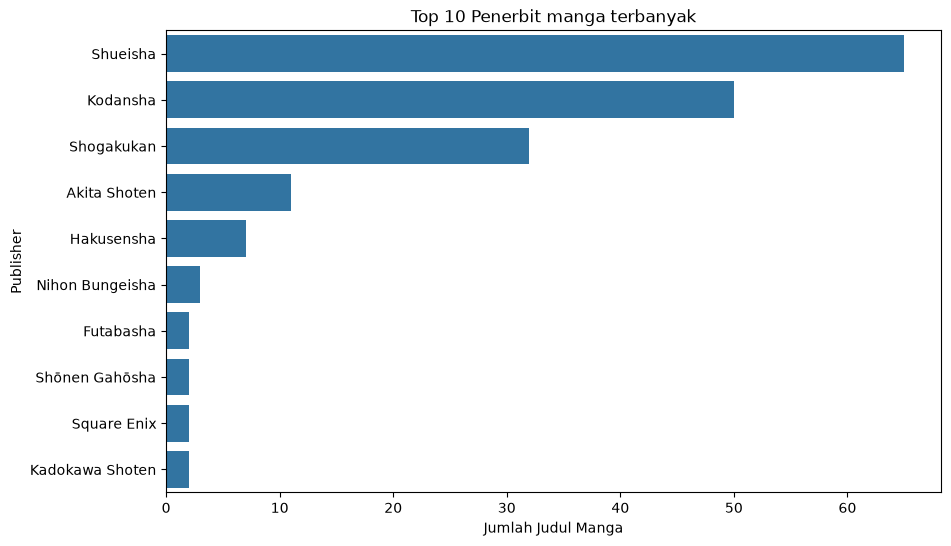

In [18]:
plt.figure(figsize=(10, 6))
# Menampilkan 10 penerbit teratas dengan jumlah judul terbanyak
top_publishers = df["Publisher"].value_counts().head(10).index
sns.countplot(data=df[df["Publisher"].isin(top_publishers)], y="Publisher", order=top_publishers)
plt.title("Top 10 Penerbit manga terbanyak")
plt.xlabel("Jumlah Judul Manga")
plt.ylabel("Publisher")
plt.show()

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Manga series                            187 non-null    str    
 1   Author(s)                               187 non-null    str    
 2   Publisher                               187 non-null    str    
 3   Demographic                             187 non-null    str    
 4   No. of collected volumes                187 non-null    int64  
 5   Serialized                              187 non-null    str    
 6   Approximate sales in million(s)         187 non-null    float64
 7   Average sales per volume in million(s)  187 non-null    float64
dtypes: float64(2), int64(1), str(5)
memory usage: 11.8 KB


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

X = df[["Approximate sales in million(s)", "No. of collected volumes"]]
y = df["Average sales per volume in million(s)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

prediksi = model.predict(X_test)
print("Nilai MAE: ", mean_absolute_error(y_test, prediksi))
print("Nilai R2 Test: ", r2_score(y_test, prediksi))
print("Nilai R2 Train: ", r2_score(y_train, model.predict(X_train)))

Nilai MAE:  0.33126396093980803
Nilai R2 Test:  0.6443143218020978
Nilai R2 Train:  0.5617682052000351
